# 1. Audio Analysis

## Import Libraries

In [93]:
from scipy.io import wavfile
import scipy

import numpy as np
import numpy.fft as fft

import matplotlib.pyplot as plt

from matplotlib.axes import Axes

import os

In [94]:
AUDIO_DIR = '6532136721'

## Analysis

In [95]:

def plot_audio(audio_path:str) -> None:
    def init_ax() -> Axes:
        _, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
        ax[0].set_title('Time domain x(t)')
        ax[0].set_xlabel('time[second]')
        ax[1].set_title('Frequency domain |X(f)|')
        ax[1].set_xlabel('Frequency[Hz]')
        return ax
    ax = init_ax()
    sr, x = wavfile.read(audio_path)
    # Time domain
    x_mono = x[:, 0] # extract only one channeli
    ax[0].plot(np.arange(len(x)) / sr, x_mono, lw=0.2)

    # Frequency domain
    dfted_x = np.abs( fft.fft(x_mono) ) # np.abs for imaginary number is a**2 + b**2 for imaginary number a+jb
    freq = fft.fftfreq(len(x_mono), d=1/sr) # d : Sample spacing (inverse of the sampling rate)
    ax[1].plot(freq, dfted_x, lw=0.2)


    dfted_x[0] = 0 # exclude DC component
    sorted_index = dfted_x.argsort()[::-1] # sort index by magnitude (descending order)

    print(*np.abs(freq[sorted_index][:6:2]), sep='\t') 
    # Top 3 highest dominant frequencies (due to complex conjugate symmetry, I need to set step=2, i.e, top magitude of order 2*i == top magitude of order 2*i+1)
    # The reason I put np.abs because if the value(magnitude) is equal, so the sorting algorithm randomly put either $f$ or $-f$ first and the other second.

    print(*dfted_x[sorted_index][:6:2], sep='\t') # print correspond magnitude

    plt.show()


plt.show()

### file1.wav

9780.04495992702	9781.481722812276	5517.169479377077
562653300320.6016	507358550179.85565	445359697624.7051


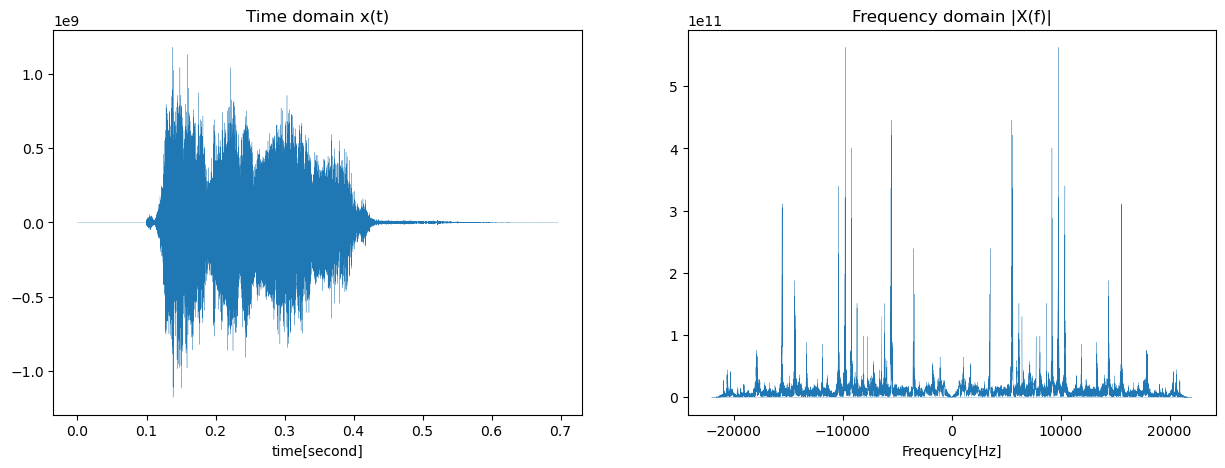

In [97]:
plot_audio(os.path.join(AUDIO_DIR, 'file1.wav'))

### file2.wav

556.5182450043441	557.4761077324066	547.897480451781
1158205165264.6455	1157527790108.0676	1068673045690.1824


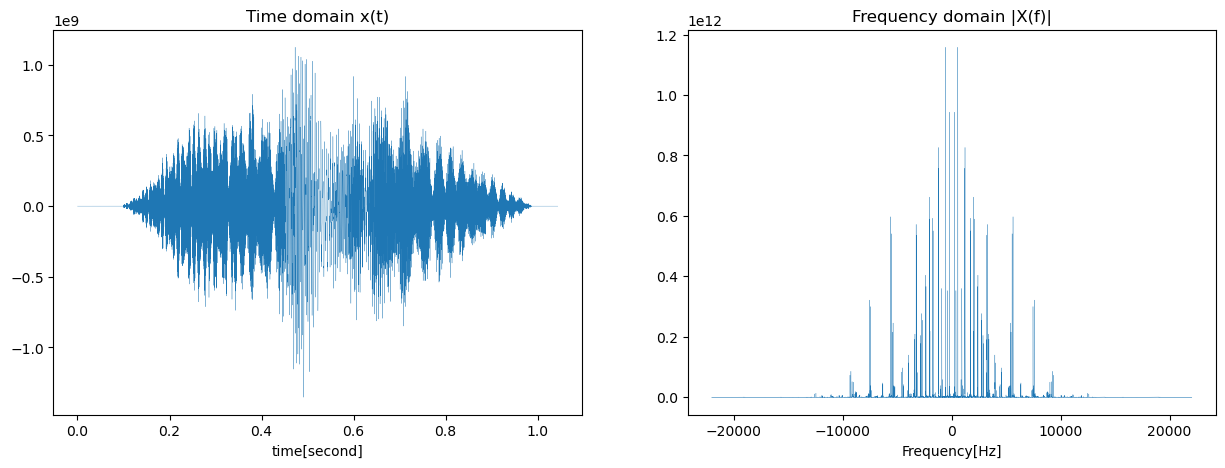

In [98]:
plot_audio(os.path.join(AUDIO_DIR, 'file2.wav'))

# 2.

## 2.1

Find $h[n]$
\begin{align*}
y[n] &= a_1x[n] + a_2x[n+n_1] + a_3x[n+n_2] \\
y[n] &= 4x[n] -2x[n-1] -2x[n-2] \\
x*h[n] &= 4x[n] -2x[n-1] -2x[n-2] \\
x*h[n] &= \sum_{k=-\infty}^{\infty}x[n-k]h[k]
\end{align*}

\begin{align}
\therefore h[n] = \begin{cases}
      4, & \text{if}\ n=0 \\
      -2, & \text{if}\ n=1 \\
      -2, & \text{if}\ n=2 \\
      0, & \text{otherwise}
\end{cases}
\end{align}

find $H(e^{j\omega})$
\begin{align*}
H(e^{jw}) &= \sum_{n=-\infty}^{\infty}h[n]e^{-j\omega n} \\
          &= h[0]e^{0} + h[1]e^{-j\omega} + h[2]e^{-2j\omega} \\
          &= 4 - 2e^{-j\omega} -2e^{-2j\omega}
\end{align*}


## 2.2

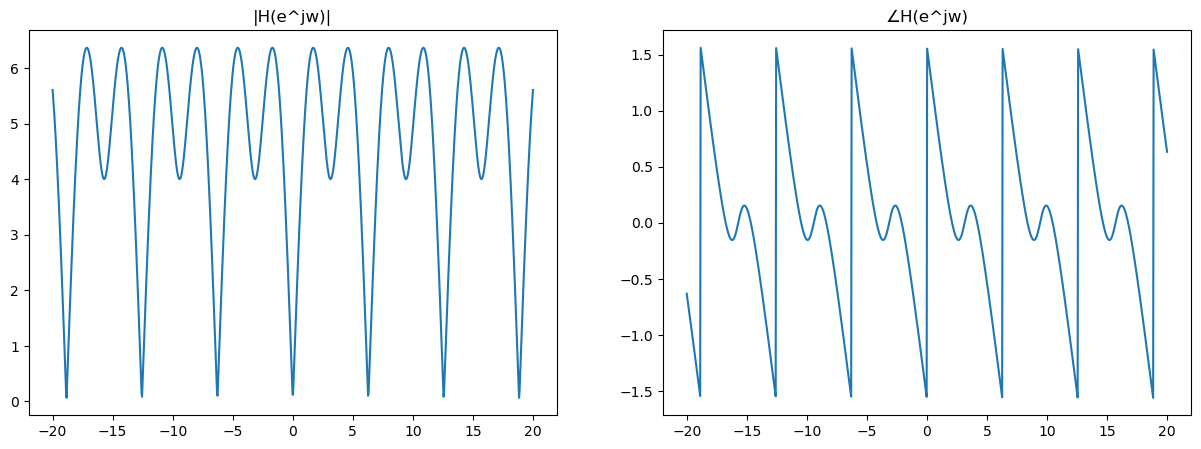

In [99]:
w = np.linspace(-20, 20, 1_000)
H = 4 - 2*np.exp(-1j*w) - 2*np.exp(-2j*w)


_, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

ax[0].set_title('|H(e^jw)|')
ax[1].set_title('∠H(e^jw)')

mag = np.abs(H)
phase = np.angle(H)

ax[0].plot(w, mag)
ax[1].plot(w, phase)

plt.show()

## 2.3
Student ID: 6532136721

Convolution

\begin{array}{cccccccccccc}
&&6&5&3&2&1&3&6&7&2&1 \\
 &&&&&&&&&4&-2&-2 \\
 \\[-10pt]
  \hline
  &&-12&-10&-6&-4&-2&-6&-12&-14&-4&-2 \\
&-12&-10&-6&-4&-2&-6&-12&-14&-4&-2& \\
24&20&12&8&4&12&24&28&8&4&& \\
 
 \hline
 \\[-10pt]
24&8&-10&-8&-6&6&16&10&-18&-14&-6&-2 \\
  \hline
  \hline
\end{array}
$y = \{24, 8, -10, -8, -6, 6, 16, 10, -18, -14, -6, -2\}$

Find DFT

\begin{align*}
Y[k] &= \sum_{n=0}^{11} y[n]e^{-j\frac{2\pi}{12} nk}
\end{align*}

[24, 8, -10, -8, -6, 6, 16, 10, -18, -14, -6, -2]
[0.00000000e+00+0.00000000e+00j 3.33974596e+00-1.59282032e+01j
 9.30000000e+01+1.73205081e+00j 4.58933059e-16-1.55431223e-15j
 2.70000000e+01-2.59807621e+01j 2.06602540e+01-2.07179677e+00j
 0.00000000e+00-3.56458876e-14j 2.06602540e+01+2.07179677e+00j
 2.70000000e+01+2.59807621e+01j 2.43803750e-14-5.46229728e-14j
 9.30000000e+01-1.73205081e+00j 3.33974596e+00+1.59282032e+01j]


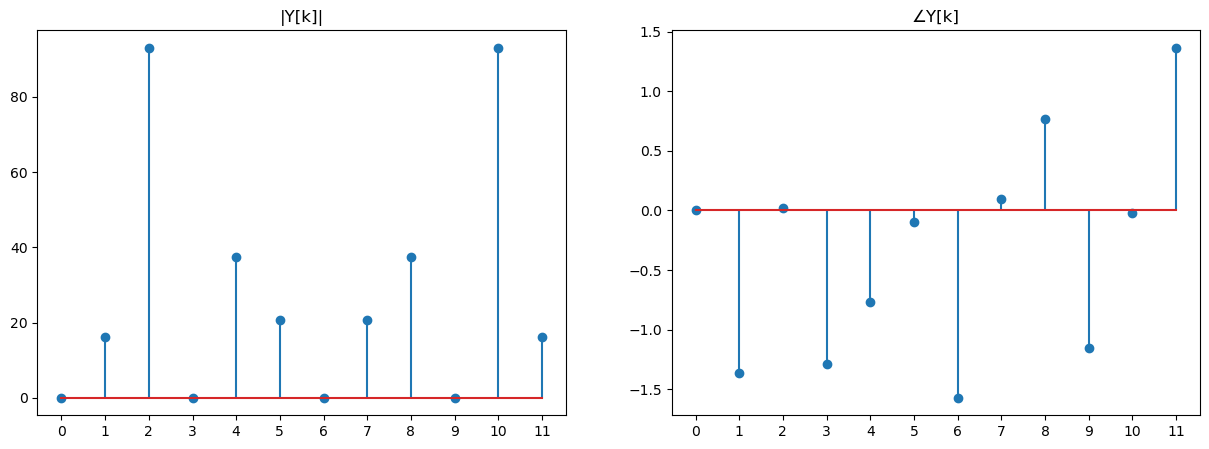

In [100]:
x = [6, 5, 3, 2, 1, 3, 6, 7, 2, 1]
h = [4, -2, -2]

y = np.convolve(x, h)
print(y.tolist())

dft_y = np.array([
   sum( yn * np.exp(-1j * 2 * np.pi * n * k / len(y)) for n, yn in enumerate(y) )
   for k in range(len(y))
])
print(dft_y)


freq_fft = fft.fft(x, n=12)*fft.fft(h, n=12)
assert np.all( np.abs( dft_y - freq_fft) < 1e-12 ) # Convolution check

_, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

ax[0].set_title('|Y[k]|')
ax[1].set_title('∠Y[k]')

mag = np.abs(dft_y)
phase = np.angle(dft_y)

ax[0].stem(mag)
ax[0].set_xticks(range(len(mag)))
ax[1].stem(phase)
ax[1].set_xticks(range(len(phase)))


plt.show()